<a href="https://colab.research.google.com/github/Susanta2006/Colab/blob/main/gradient_%26stochastic_gradient_descent_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
df =  pd.read_csv("bengaluru_house_prices.csv")
df.head(5)

,total_sqft,bath,price
0,1056,2.0,39.07
1,2600,5.0,120.00
2,1440,2.0,62.00
3,1521,3.0,95.00
4,1200,2.0,51.00


In [ ]:
from sklearn import preprocessing as pp
import numpy as np # Import numpy for NaN

sx = pp.MinMaxScaler()
sy = pp.MinMaxScaler()

def convert_sqft_to_num(x):
    try:
        tokens = str(x).split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except ValueError:
        return np.nan # Return NaN for values that cannot be converted

# Apply the conversion function to the 'total_sqft' column
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

# Identify features that will be scaled
features_for_scaling = ['total_sqft', 'bath'] # Based on the df state in kernel

# Drop rows where any of the features for scaling have NaN values
df.dropna(subset=features_for_scaling, inplace=True)

# Now, scaled_X can be computed safely
scaled_X = sx.fit_transform(df.drop("price",axis="columns"))
print(scaled_X)
scaled_y = sy.fit_transform(df["price"].values.reshape(df.shape[0],1))
print(scaled_y)

[[0.02018328 0.02564103]
 [0.04972164 0.1025641 ]
 [0.02752961 0.02564103]
 ...
 [0.02180942 0.02564103]
 [0.08968644 0.07692308]
 [0.01050296 0.        ]]
[[0.00864978]
 [0.0311804 ]
 [0.01503341]
 ...
 [0.01447661]
 [0.13363029]
 [0.00250557]]


In [ ]:
w=np.ones(shape=(2))

In [ ]:
np.dot(w, scaled_X.T)

array([0.0458243 , 0.15228575, 0.05317063, ..., 0.04745044, 0.16660952,
       0.01050296])

In [ ]:
def batch_gradient_descent(X,y_true,epochs, lr = 0.01):
  number_of_features = X.shape[1]

  w = np.ones(shape=(number_of_features))
  b = 0
  total_samples = X.shape[0]

  cost_list =[]
  epoch_list = []

  for i in range(epochs):
    y_pred = np.dot(w, scaled_X.T) + b      #w1*total_sqft + w2*bath + b
    w_grad = -(2/total_samples) * (X.T.dot(y_true - y_pred))
    b_grad = -(2/total_samples)* np.sum(y_true-y_pred)

    w = w - lr * w_grad
    b = float(b - lr * b_grad)

    cost = float(np.mean(np.square(y_true - y_pred)))

    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w, b, cost, epoch_list, cost_list

w, b, cost, cost_list, epoch_list = batch_gradient_descent(scaled_X, scaled_y.reshape(scaled_y.shape[0],), 1000)

w, b, cost

(array([0.99253529, 0.98144827]), -0.04308731395917228, 0.00163670271683426)

Text(0, 0.5, 'Cost')

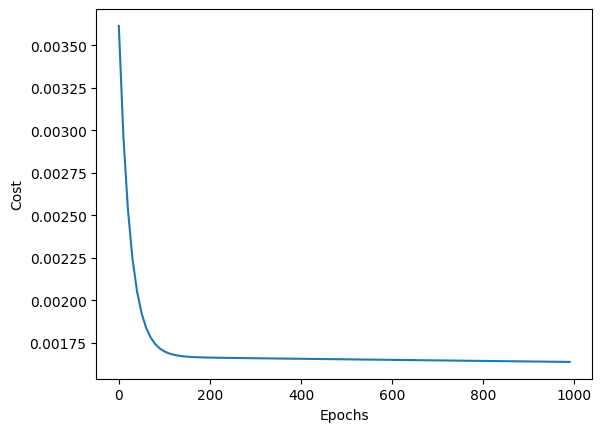

In [ ]:
plt.plot(cost_list, epoch_list)
plt.xlabel("Epochs")
plt.ylabel("Cost")

In [ ]:
def predict(total_sqft, bath, w, b):
  # Create a DataFrame with correct column names for consistent scaling
  input_data = pd.DataFrame([[total_sqft, bath]], columns=['total_sqft', 'bath'])
  scale_X = sx.transform(input_data)[0]

  scaled_price = w[0] * scale_X[0] + w[1]* scale_X[1] + b

  # Cast the final result to a Python float
  return float(sy.inverse_transform([[scaled_price]])[0][0])

predict(1056, 2, w, b)

15.581417624104311

In [ ]:
predict(2600,5,w,b)

392.0729208341738

In [ ]:
import random
def stochastic_gradient_descent(X, y_true, epochs, learning_rate=0.001):
    number_of_features = X.shape[1]

    w = np.ones(shape=(number_of_features))
    b = 0
    total_samples = X.shape[0]

    cost_list = []
    epochs_list = []

    for i in range(epochs):
      random_index = random.randint(0, total_samples - 1)
      sample_x = X[random_index]
      sample_y = y_true[random_index]

      y_pred = np.dot(w_sgd, sample_x.T) + b_sgd
      w_grad = -(2/total_samples) * (sample_x.T.dot(sample_y-y_pred))
      b_grad = -(2/total_samples)* (sample_y-y_pred)

      w = w - learning_rate * w_grad
      b = float(b - learning_rate * b)

      cost = np.square(sample_y-y_pred)

      if i%100 == 0:
        cost_list.append(cost)
        epochs_list.append(i)

    return w, b, cost, epochs_list, cost_list

w_sgd, b_sgd, cost_sgd, epochs_list_sgd, cost_list_sgd = stochastic_gradient_descent(scaled_X, scaled_y.reshape(scaled_y.shape[0],), 10000)

w_sgd, b_sgd, cost_sgd

(array([0.99999763, 0.9999958 ]), 0.0, np.float64(0.003764327268876996))

Text(0, 0.5, 'Cost')

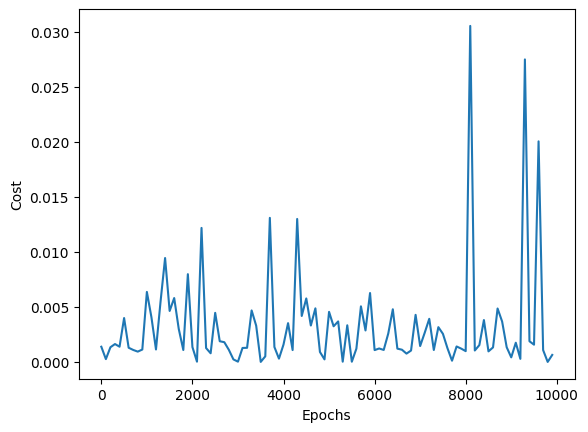

In [ ]:
plt.plot(epochs_list_sgd, cost_list_sgd)
plt.xlabel("Epochs")
plt.ylabel("Cost")

In [ ]:
predict(1056, 2, w_sgd, b_sgd)

172.60033154798612